# MIRI f21 - JWST: All Regions Plotted

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
import os
import shutil
from astropy.io import fits # importing fits 
from astropy.utils.data import download_file # simple method of downloading FITS file 
from astropy.visualization import astropy_mpl_style # resource for organized plots
from astropy.visualization import ZScaleInterval, MinMaxInterval, AsinhStretch, LogStretch, ImageNormalize # quality image display/visualization
from astropy.wcs import WCS #coordinate conversion
from regions import Regions # import astropy region class


In [2]:
class DisplayData: 
    """" A class to open FITS file, display image data, 
         and plot a DS9.reg file onto the image data. """ 
    def __init__(self, filepath):
        """ Initialize through opening the data.""" 
        self.filepath = filepath
        from astropy.io import fits 
        with fits.open(filepath) as hdul: # opening file
            data = None
            header = None
            for hdu in hdul: #loops through each extension (HDU) in the list of HDUs to check if data has dimensions (thanks rav!)
                if hdu.data is not None and hdu.header.get("NAXIS",0) >= 2:
                    data = hdu.data 
                    header = hdu.header 
                    print(f"Found data in extension: {hdu.name or hdul.index(hdu)}")
                    break 
            
        if data is None:
            print("None")
       # hdu = fits.open(filepath)[1] #okay index 1 isn't always gong to work. you need to write an if statement to test 0


    def display_header(self, filepath):
        self.filepath = filepath
        from astropy.io import fits 
        with fits.open(filepath) as hdul:
            data = None
            header = None
            for hdu in hdul:
                if hdu.data is not None and hdu.header.get("NAXIS",0) >= 2:
                    data = hdu.data 
                    header = hdu.header 
                    print(f"Found data in extension: {hdu.name or hdul.index(hdu)}")
                    break 
            
        if data is None:
            print("None")

    def display_image(self, filepath, norm, vmin, vmax):
        self.filepath = filepath 
        self.norm = norm
        self.vmin = vmin
        self.vmax = vmax
        #brightness control
        #hdu = fits.open(filepath)[1]
        #data = hdu.data
        #header = hdu.header 
        from astropy.io import fits
        with fits.open(filepath) as hdul:
            data = None
            header = None
            for hdu in hdul:
                if hdu.data is not None and hdu.header.get("NAXIS",0) >= 2:
                    data = hdu.data 
                    header = hdu.header 
                    print(f"Found data in extension: {hdu.name or hdul.index(hdu)}")
                    break 
            
        if data is None:
            print("None")



        plt.figure(figsize=(8, 8))
        plt.imshow(data, cmap="gray", origin="lower", norm=self.norm, vmin=self.vmin, vmax=self.vmax) #figure out a way to add normalization parameter into this function
        plt.colorbar(label="Intensity", fraction=0.0146, aspect=20)
    

    
    def plot_region(self, filepath, disk_regionfile, ring_regionfile, bar_regionfile, center_regionfile, spiralarms_regionfile, norm, vmin, vmax, figname):
        self.filepath = filepath
        self.disk_regionfile = None #changed all to None to account for the fact that not every data set has a regionfile for certain structures
        self.ring_regionfile = None
        self.bar_regionfile = None
        self.center_regionfile = None
        self.spiralarms_regionfile = None
        self.norm = norm 
        self.vmin = vmin
        self.vmax= vmax 
        self.figname = figname
        from astropy.io import fits 
        from astropy.wcs import WCS
        with fits.open(filepath) as hdul:
            data = None
            header = None
            for hdu in hdul:
                if hdu.data is not None and hdu.header.get("NAXIS",0) >= 2:
                    data = hdu.data 
                    header = hdu.header 
                    print(f"Found data in extension: {hdu.name or hdul.index(hdu)}")
                    break 
            
        if data is None:
            print("None")
            
        wcs = WCS(header) #see https://astronomy.stackexchange.com/questions/51673/how-to-slice-wcs-in-a-fits-file
        # access region file via parsing & converting data from wcs to pixel. the 0 is for the FIRST region plotted
        # for i in regionfile??? what i want to do is for each region in the regionfile, plot each region if an index exists for that region
        fig, ax = plt.subplots()
        ax.imshow(data, cmap='gray', origin='lower', norm=self.norm, vmin=self.vmin, vmax=self.vmax) 

        
        if disk_regionfile is not None: #if the regionfile DOES exist, read the regionfile data
            disk_region = Regions.read(disk_regionfile)[0].to_pixel(wcs)
            disk_region.plot(ax=ax, color='red', lw=2.0)
        if ring_regionfile is not None:
            ring_region1 = Regions.read(ring_regionfile)[0].to_pixel(wcs) # access region file via
            ring_region2 = Regions.read(ring_regionfile)[1].to_pixel(wcs) # the one corresponds to
            ring_region1.plot(ax=ax, color= 'blue', lw=2.0) 
            ring_region2.plot(ax=ax, color='blue', lw=2.0)
        ring_region2.plot(ax=ax, color='blue', lw=2.0)
        if bar_regionfile is not None:
            bar_region = Regions.read(bar_regionfile)[0].to_pixel(wcs)
            bar_region2 = Regions.read(bar_regionfile)[1].to_pixel(wcs)
            bar_region.plot(ax=ax, color= 'green', lw=1.0)
            bar_region2.plot(ax=ax, color= 'green', lw=1.0)
        if center_regionfile is not None:
            center_region = Regions.read(center_regionfile)[0].to_pixel(wcs)
            center_region.plot(ax=ax, color='orange', lw=1.0)
        if spiralarms_regionfile is not None:
            spiralarms_region1 = Regions.read(spiralarms_regionfile)[0].to_pixel(wcs)
            spiralarms_region2 = Regions.read(spiralarms_regionfile)[1].to_pixel(wcs)
            spiralarms_region1.plot(ax=ax, color='pink', lw=2.0)
            spiralarms_region2.plot(ax=ax, color='pink', lw=2.0)
    
        
        plt.savefig(figname)
                        

Found data in extension: SCI
Found data in extension: SCI


Set DATE-AVG to '2023-11-04T21:47:11.691' from MJD-AVG.
Set DATE-END to '2023-11-05T05:40:24.115' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    25.154213 from OBSGEO-[XYZ].
Set OBSGEO-H to 1482168350.904 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
C:\Users\Lamat\AppData\Local\Programs\Python\Python314\Lib\site-packages\regions\shapes\ellipse.py:222: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Ellipse(xy=xy, width=width, height=height, angle=angle,
C:\Users\Lamat\AppData\Local\Programs\Python\Python314\Lib\site-packages\regions\shapes\rectangle.py:219: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Rectangle(xy=xy, width=width, height=height,
C:\Users\Lamat\AppData\Local\Programs\Python\Python314\Lib\site-packages\regions\shapes\polygon.py:225: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Polygon(xy=xy, **mpl_kwar

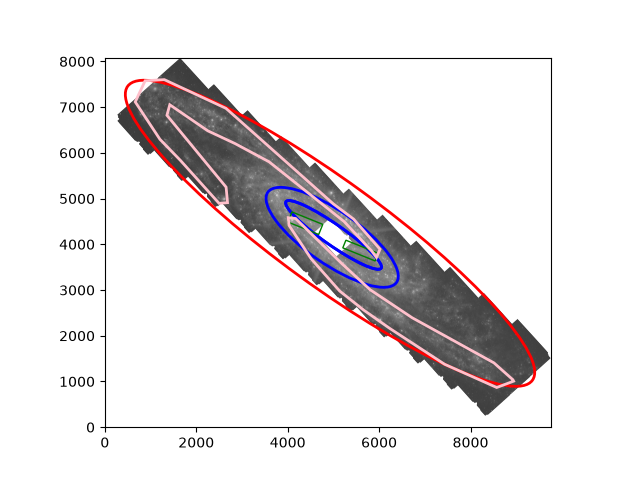

In [4]:
%matplotlib widget
mirif21_file = r"C:\Users\Lamat\OneDrive - The Ohio State University\Lamat NGC 253 Environment Mask\Plotting Regions\ngc0253_miri_lv3_f2100w_i2d_align.fits"
mirif21_data = DisplayData(mirif21_file)
mirif21_disk_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/disk_mirif21_regionfile_jwst_adjusted713026.reg"
mirif21_ring_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/ring_mirif21_regionfile_jwst_thicker.reg"
mirif21_bar_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/bar_f21miri_regionfile_jwst_twoboxes_updated.reg"
mirif21_center_regionfile = None
mirif21_spiralarms_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/spiralarms_mirif21_regionfile_jwst.reg"
mirif21_data.plot_region(mirif21_file, mirif21_disk_regionfile, mirif21_ring_regionfile, mirif21_bar_regionfile, mirif21_center_regionfile, mirif21_spiralarms_regionfile, 'asinh', None, None, 'mirif21 map')